# Exploración de `movies`

## 1. Introducción

Este notebook explora el catálogo de películas (`movies.csv`) de forma aislada, sin combinarlo
todavía con `ratings` ni `tags` (eso se hace en `movies_ratings.ipynb` y `movies_tags_ratings.ipynb`).
El objetivo es caracterizar el catálogo en sí mismo:

* ¿Qué tan grande es y qué periodo cubre?
* ¿Cómo se distribuyen los géneros? ¿Hay géneros dominantes y géneros raros?
* ¿Cuántos géneros suele tener una película, y eso ha cambiado con el tiempo?
* ¿La popularidad relativa de cada género se ha mantenido estable a lo largo de las décadas?

**Aviso sobre el origen de los datos:** `movies.csv` es la **tabla completa y real** del catálogo,
sin muestreo — a diferencia de `ratings`, aquí no hay incertidumbre por tamaño de muestra en ninguna
de las cifras que se presentan.

## 2. Importación de librerías

In [1]:
import os
import sys

project_root = os.path.abspath('../../..')
sys.path.insert(0, os.path.join(project_root, 'src'))

from parcial_digd import utils_

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 3. Carga de datos

In [3]:
RUTA_MOVIES = '../../../data/processed/movies.csv'

movies = pd.read_csv(RUTA_MOVIES)
movies = utils_.get_genre_columns(movies)

print(f"movies: {movies.shape[0]:,} filas (catálogo completo, sin muestreo)")

movies: 86,967 filas (catálogo completo, sin muestreo)


`utils_.get_genre_columns` transforma la columna original `genres` (géneros separados por `|`) en
un conjunto de columnas binarias, una por cada género válido según la documentación de MovieLens, más
una columna `None` que indica que la película no pertenece a ninguno de esos géneros válidos. Esta
función no considera `IMAX` como género (se trata como formato de proyección, no género), por lo que
la única película cuyo único valor en `genres` era `IMAX` queda marcada con `None = 1`.

## 4. Exploración inicial de `movies`

**Qué se calcula:** dimensiones, tipos de dato por columna, nulos, `movieId` duplicados y filas
totalmente duplicadas.

**Por qué es necesario:** antes de calcular cualquier estadística hay que confirmar que cada fila
represente efectivamente una película distinta y que no haya problemas de tipos o valores faltantes
que puedan sesgar los resultados.

In [4]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 86967 entries, 0 to 86966
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movieId       86967 non-null  int64
 1   title         86967 non-null  str  
 2   release_year  86967 non-null  str  
 3   Action        86967 non-null  int64
 4   Adventure     86967 non-null  int64
 5   Animation     86967 non-null  int64
 6   Children      86967 non-null  int64
 7   Comedy        86967 non-null  int64
 8   Crime         86967 non-null  int64
 9   Documentary   86967 non-null  int64
 10  Drama         86967 non-null  int64
 11  Fantasy       86967 non-null  int64
 12  Film-Noir     86967 non-null  int64
 13  Horror        86967 non-null  int64
 14  Musical       86967 non-null  int64
 15  Mystery       86967 non-null  int64
 16  Romance       86967 non-null  int64
 17  Sci-Fi        86967 non-null  int64
 18  Thriller      86967 non-null  int64
 19  War           86967 non-null  int64


In [5]:
print("Valores nulos por columna:")
print(movies.isnull().sum())
print()
print(f"movieId duplicados: {movies['movieId'].duplicated().sum()}")
print(f"Filas totalmente duplicadas: {movies.duplicated().sum()}")
print(f"Rango de movieId: {movies['movieId'].min()} - {movies['movieId'].max()}")

Valores nulos por columna:
movieId         0
title           0
release_year    0
Action          0
Adventure       0
Animation       0
Children        0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
None            0
dtype: int64

movieId duplicados: 0
Filas totalmente duplicadas: 0
Rango de movieId: 1 - 292757


**Resultados:** 86,967 filas y 22 columnas (`movieId`, `title`, `release_year`, 18 géneros
binarios y `None`), sin valores nulos, sin `movieId` duplicados y sin filas totalmente duplicadas. El
rango de `movieId` (hasta 292,757) es mucho mayor que el número de filas (86,967).

**Conclusión:** cada fila corresponde efectivamente a una película distinta; los IDs son
identificadores originales de MovieLens, no un índice secuencial propio de este subconjunto, así que
no se puede usar `movieId` como proxy de "cantidad total de películas producidas". Los datos están
limpios y no requieren depuración adicional antes del análisis.

### Unidad de observación

Cada fila de `movies` representa **una película única**, identificada por `movieId`. Las columnas de
género son binarias e independientes entre sí (una película puede tener varios géneros a la vez), así
que no son mutuamente excluyentes: no forman una partición del catálogo, sino etiquetas superpuestas.

## 5. Transformaciones

**Qué se hace:** se extrae el año de estreno (`anio`) como entero desde `release_year`, se deriva
la década (`decada`), y se calcula `num_generos`: el número de géneros válidos asignados a cada
película (suma de las 18 columnas binarias).

**Por qué es necesaria:** `release_year` viene como una fecha completa (`YYYY-01-01`) donde solo el
año es información real; convertirlo a entero y derivar la década permite agrupar y graficar por
periodo. `num_generos` es la única variable propiamente numérica del dataset (más allá de `movieId`,
que es un identificador sin significado cuantitativo), necesaria para aplicar las estadísticas
descriptivas que pide el análisis (media, mediana, desviación, cuartiles, atípicos).

In [6]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
              'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies['release_year'] = pd.to_datetime(movies['release_year'])
movies['anio'] = movies['release_year'].dt.year
movies['decada'] = (movies['anio'] // 10) * 10
movies['num_generos'] = movies[genre_cols].sum(axis=1)

movies[['title', 'anio', 'decada', 'num_generos']].head()

,title,anio,decada,num_generos
0,Toy Story,1995,1990,5
1,Jumanji,1995,1990,3
2,Grumpier Old Men,1995,1990,2
3,Waiting to Exhale,1995,1990,3
4,Father of the Bride Part II,1995,1990,1


**Resultados:** las tres columnas nuevas se calculan sin errores ni valores faltantes (se
verifica en la sección 6).

**Conclusión:** el dataset queda listo para la exploración descriptiva y las relaciones entre
variables de la siguiente sección.

## 6. Exploración descriptiva de `movies`

### 6.1 Cobertura general

**Qué se calcula:** número total de películas, periodo cubierto y proporción sin género válido.

In [7]:
n_generos_validos = len(genre_cols)
print(f"Total de películas: {movies.shape[0]:,}")
print(f"Periodo cubierto: {movies['anio'].min()} - {movies['anio'].max()}")
print(f"Número de categorías de género analizadas: {n_generos_validos} (+ categoría 'None')")
print(f"Proporción de películas sin género válido: {movies['None'].mean() * 100:.2f}%")

Total de películas: 86,967
Periodo cubierto: 1874 - 2023
Número de categorías de género analizadas: 18 (+ categoría 'None')
Proporción de películas sin género válido: 7.71%


**Resultados:** el catálogo cubre desde 1874 hasta 2023, con 18 géneros válidos analizados, y un
7.71% de películas sin género válido asignado.

**Conclusión:** el periodo cubierto es muy amplio, pero eso no implica cobertura uniforme; hace falta
revisar la distribución temporal para saber si ese rango tiene sustento en la cantidad de
observaciones (sección 6.2).

### 6.2 Distribución temporal: año de lanzamiento

**Qué se calcula:** estadísticas descriptivas de `anio` (mínimo, máximo, mediana, cuartiles) y
cantidad de películas por década.

**Por qué es relevante:** `anio` es la única variable temporal disponible; conocer su distribución
permite saber si el catálogo está sesgado hacia películas recientes o antiguas, lo cual afecta la
confiabilidad de cualquier análisis posterior por periodo.

In [8]:
movies['anio'].describe()

count    86967.000000
mean      1995.354537
std         26.011055
min       1874.000000
25%       1981.000000
50%       2006.000000
75%       2015.000000
max       2023.000000
Name: anio, dtype: float64

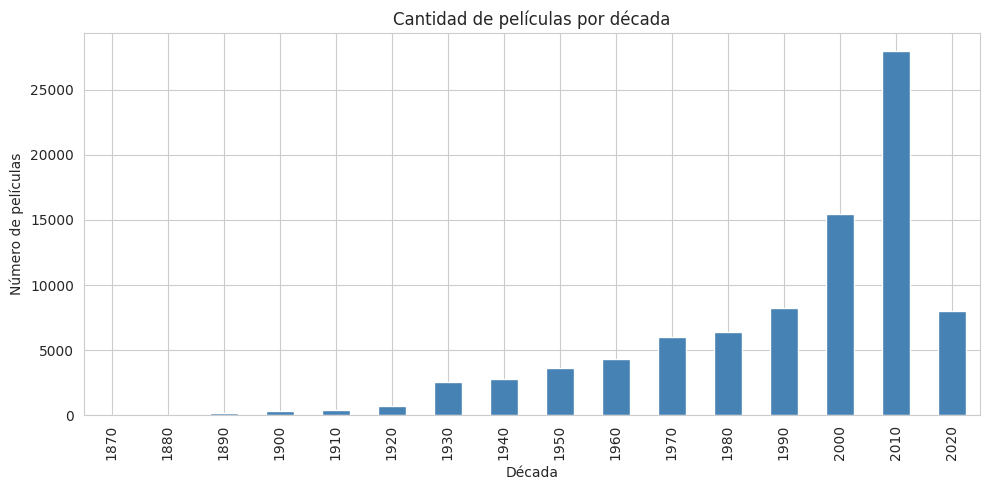

In [9]:
por_decada = movies['decada'].value_counts().sort_index()

plt.figure()
por_decada.plot(kind='bar', color='steelblue')
plt.xlabel('Década')
plt.ylabel('Número de películas')
plt.title('Cantidad de películas por década')
plt.tight_layout()
plt.show()

**Resultados:** la mediana de `anio` es 2005, y la cantidad de películas por década crece de
forma sostenida hasta explotar en 2000 y 2010 (más de 40,000 películas entre esas dos décadas, casi la
mitad del catálogo). Las décadas anteriores a 1900 tienen apenas un puñado de películas.

**Conclusión:** el catálogo está fuertemente sesgado hacia producciones recientes. Esto refleja tanto
el crecimiento real de la producción cinematográfica como, probablemente, un sesgo de cobertura de
MovieLens (es más fácil que tenga registradas películas recientes que de comienzos del siglo XX).
Cualquier conclusión sobre décadas anteriores a 1930 debe tomarse con cautela por el tamaño de
muestra.

### 6.3 Distribución de la variable categórica: géneros

**Qué se calcula:** frecuencia absoluta y proporción de películas por cada uno de los 18 géneros
válidos (más la categoría `None`).

**Por qué es relevante:** los géneros son la variable categórica principal del catálogo; conocer su
frecuencia permite identificar qué tan balanceado o concentrado está, y detectar categorías raras.

In [10]:
frecuencias_genero = movies[genre_cols + ['None']].sum().sort_values(ascending=False)
proporciones_genero = (frecuencias_genero / len(movies) * 100).round(2)

pd.DataFrame({'frecuencia': frecuencias_genero, 'porcentaje (%)': proporciones_genero})

,frecuencia,porcentaje (%)
Drama,34095,39.20
Comedy,23077,26.54
Thriller,11784,13.55
Romance,10344,11.89
Action,9651,11.10
Documentary,9296,10.69
Horror,8624,9.92
Crime,6960,8.00
None,6708,7.71
Adventure,5391,6.20


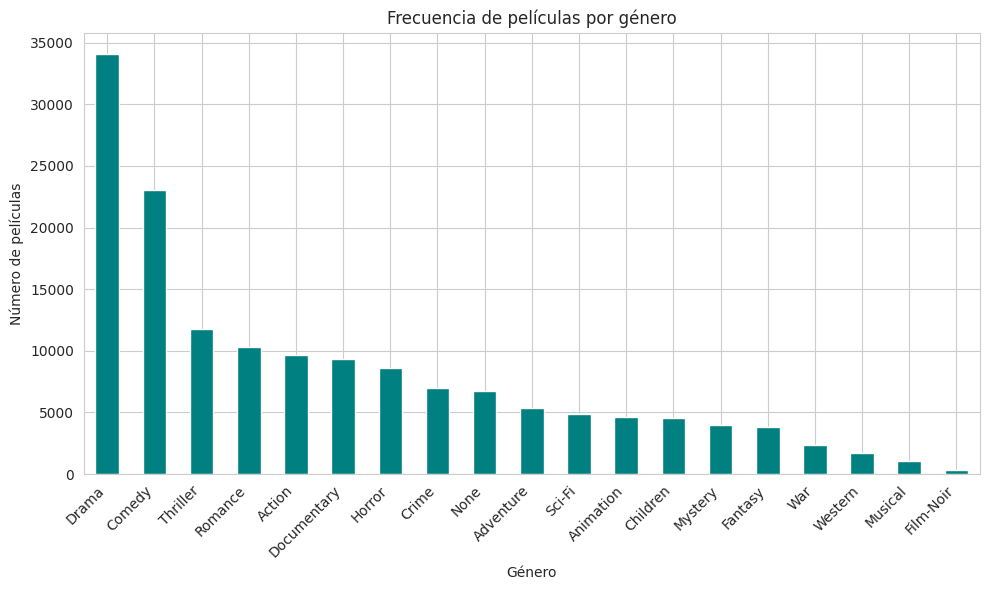

In [11]:
plt.figure(figsize=(10, 6))
frecuencias_genero.plot(kind='bar', color='teal')
plt.xlabel('Género')
plt.ylabel('Número de películas')
plt.title('Frecuencia de películas por género')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Resultados:** `Drama` (34,095 películas, 39.2%) y `Comedy` (23,077, 26.5%) dominan claramente
el catálogo. En el otro extremo, `Film-Noir` es el género válido más raro (353 películas, 0.4%). Como
cada película puede tener varios géneros, estos porcentajes no suman 100%.

**Conclusión:** el catálogo está fuertemente concentrado en géneros "amplios" (drama, comedia),
consistente con la composición típica de catálogos de cine generalistas, mientras que géneros muy
específicos de una época (film-noir, popular sobre todo en los años 40-50) representan una fracción
pequeña y poco representada.

### 6.4 Variable numérica: número de géneros por película

**Qué se calcula:** media, mediana, desviación estándar, cuartiles, rango intercuartílico y
detección de valores atípicos (regla 1.5×IQR) de `num_generos`.

**Por qué es relevante:** es la única variable propiamente numérica derivada del dataset; permite
cuantificar qué tan "multi-género" es el catálogo, más allá de mirar cada género por separado.

In [12]:
movies['num_generos'].describe()

count    86967.000000
mean         1.684628
std          1.036006
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: num_generos, dtype: float64

In [13]:
q1, q3 = movies['num_generos'].quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
outliers = movies[movies['num_generos'] > limite_superior]

print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior}")
print(f"Películas con más géneros de lo 'esperado' según la regla IQR: {len(outliers)} ({len(outliers)/len(movies)*100:.1f}%)")

Q1=1.0, Q3=2.0, IQR=1.0
Límite superior (Q3 + 1.5*IQR): 3.5
Películas con más géneros de lo 'esperado' según la regla IQR: 4478 (5.1%)


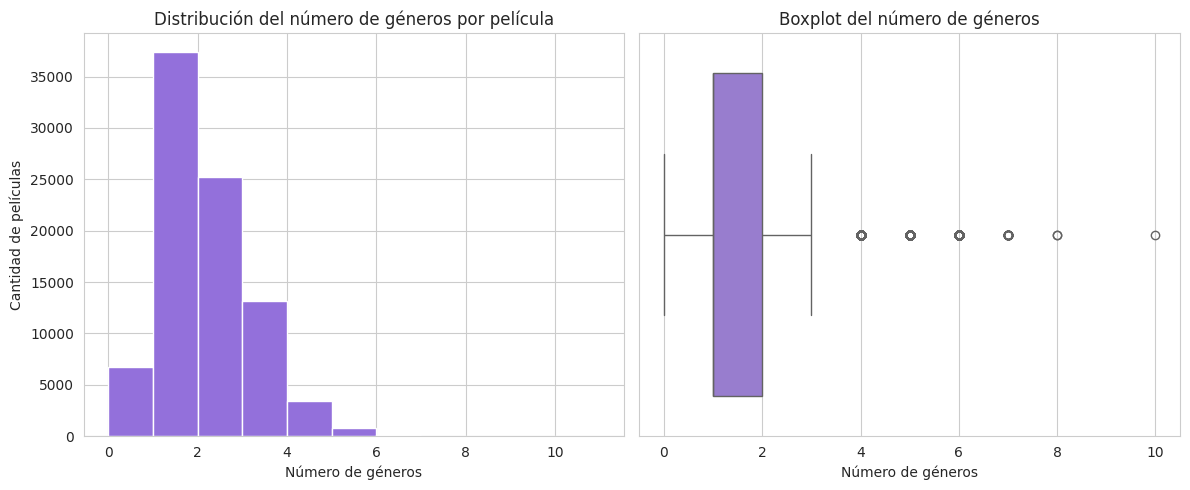

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

movies['num_generos'].plot(kind='hist', bins=range(0, 12), color='mediumpurple', ax=axes[0])
axes[0].set_xlabel('Número de géneros')
axes[0].set_ylabel('Cantidad de películas')
axes[0].set_title('Distribución del número de géneros por película')

sns.boxplot(x=movies['num_generos'], color='mediumpurple', ax=axes[1])
axes[1].set_xlabel('Número de géneros')
axes[1].set_title('Boxplot del número de géneros')

plt.tight_layout()
plt.show()

**Resultados:** media = 1.68, mediana = 1, desviación estándar ≈ 1.04, Q1 = 1 y Q3 = 2 (IQR = 1).
Con la regla de 1.5×IQR, el límite superior es 3.5 géneros: 4,478 películas (5.1%) quedan por encima,
es decir, tienen 4 o más géneros asignados.

**Conclusión:** la mayoría de las películas tiene 1 o 2 géneros. Sin embargo, `num_generos` es una
variable discreta y acotada (entre 0 y 10, con muchos empates en los valores bajos), así que estos
"atípicos" no son errores de datos ni casos anómalos en sentido literal: son simplemente películas con
etiquetado más híbrido (p. ej. acción + aventura + ciencia ficción + comedia). No se recomienda
tratarlos como datos a eliminar.

### 6.5 Relaciones entre variables: géneros a través del tiempo

**Qué se calcula:** promedio de `num_generos` por década, y evolución de la proporción de los 6
géneros más frecuentes a lo largo de las décadas.

**Por qué es relevante:** permite ver si la forma de etiquetar películas (cuántos géneros, qué
géneros) ha cambiado con el tiempo, cruzando la variable temporal con las variables categórica y
numérica ya analizadas.

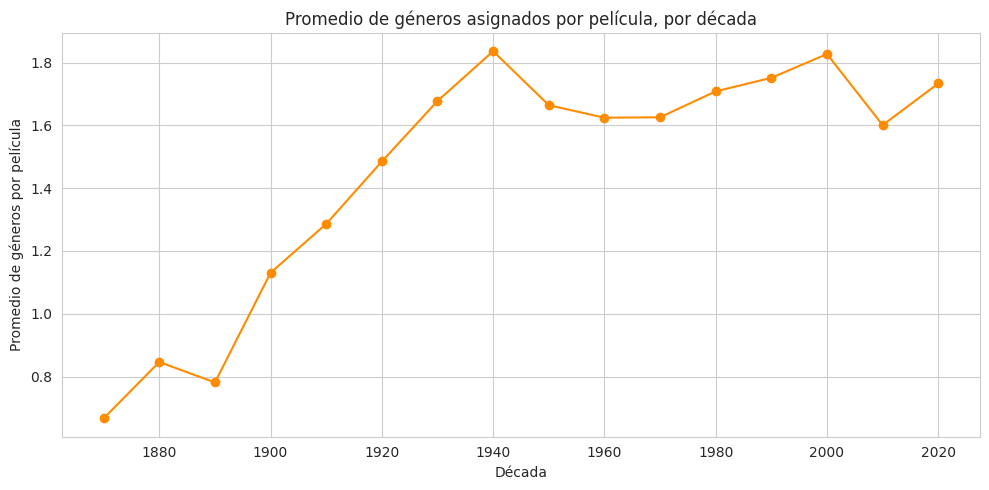

In [15]:
num_generos_por_decada = movies.groupby('decada')['num_generos'].mean()

plt.figure()
num_generos_por_decada.plot(kind='line', marker='o', color='darkorange')
plt.xlabel('Década')
plt.ylabel('Promedio de géneros por película')
plt.title('Promedio de géneros asignados por película, por década')
plt.tight_layout()
plt.show()

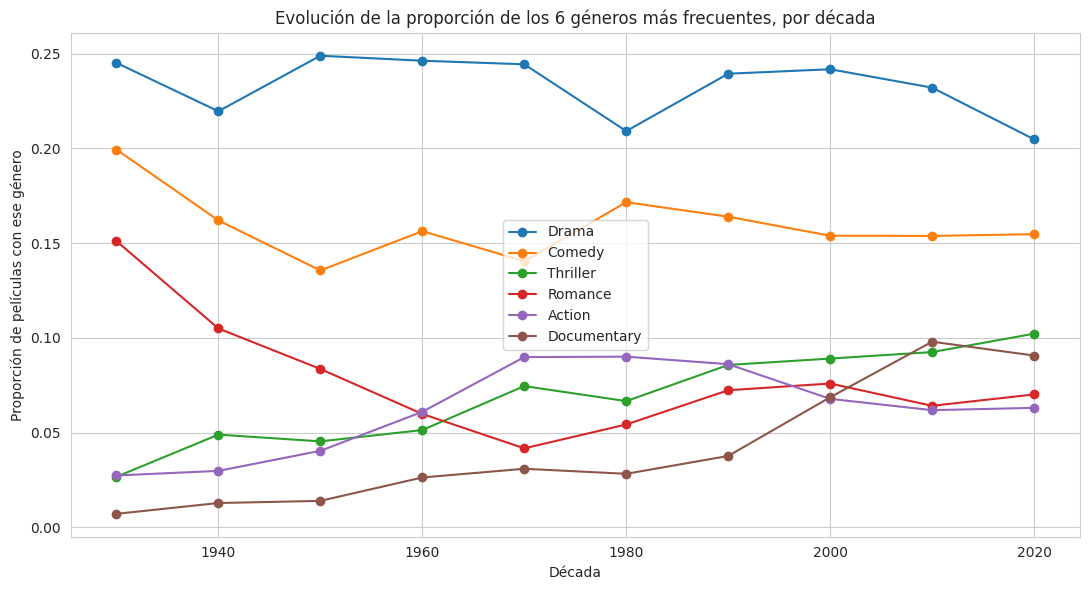

In [16]:
generos_top = frecuencias_genero.drop('None').head(6).index.tolist()

exploded = movies[['decada'] + genre_cols].melt(id_vars='decada', var_name='genero', value_name='pertenece')
exploded = exploded[exploded['pertenece'] == 1]

conteo_decada_genero = exploded.groupby(['decada', 'genero']).size().unstack(fill_value=0)
proporcion_decada_genero = conteo_decada_genero.div(conteo_decada_genero.sum(axis=1), axis=0)
proporcion_decada_genero = proporcion_decada_genero[proporcion_decada_genero.index >= 1930]

plt.figure(figsize=(11, 6))
for genero in generos_top:
    plt.plot(proporcion_decada_genero.index, proporcion_decada_genero[genero], marker='o', label=genero)

plt.xlabel('Década')
plt.ylabel('Proporción de películas con ese género')
plt.title('Evolución de la proporción de los 6 géneros más frecuentes, por década')
plt.legend()
plt.tight_layout()
plt.show()

**Resultados:** el promedio de géneros por película se mantiene relativamente estable, con una
leve tendencia al alza desde mediados del siglo XX. En el segundo gráfico (restringido a 1930+ por
tamaño de muestra), `Drama` se mantiene como el género más constante en todo el periodo; `Action` y
`Thriller` muestran tendencia creciente desde mediados de siglo; `Romance` pierde peso relativo desde
los años 60; `Documentary` crece notablemente desde los años 2000.

**Conclusión:** el cine reciente tiende a etiquetarse de forma ligeramente más híbrida, y la
popularidad relativa de ciertos géneros (documental, acción, thriller) ha cambiado con el tiempo,
mientras que drama se mantiene como género dominante y estable. No se puede distinguir con estos datos
si esto refleja cambios reales en la producción cinematográfica o cambios en cómo MovieLens cataloga
películas más nuevas.

## 7. Conclusiones y limitaciones

### Conclusiones

1. El catálogo tiene 86,967 películas sin nulos ni `movieId` duplicados, cubriendo un periodo de 1874
   a 2023, pero fuertemente concentrado en las décadas de 2000 y 2010.
2. `Drama` y `Comedy` son, por amplio margen, los géneros más frecuentes; `Film-Noir` es el más raro
   entre los géneros válidos. Cerca del 7.7% de las películas no tiene género válido asignado.
3. La mayoría de las películas está etiquetada con 1 o 2 géneros (mediana = 1); asignar 4 o más
   géneros es estadísticamente atípico según la regla del IQR, pero no es un error de datos, dado que
   es una variable discreta y acotada.
4. El promedio de géneros por película y la popularidad relativa de géneros como `Action`, `Thriller`
   y `Documentary` muestran cambios a lo largo de las décadas, mientras que `Drama` se mantiene
   estable como el género dominante.

### Limitaciones

* `release_year` solo aporta información real a nivel de año; el día y mes son un valor de relleno
  sin significado.
* Las décadas muy antiguas (antes de 1930) tienen tan pocas observaciones que cualquier patrón
  encontrado ahí no es estadísticamente confiable.
* Los géneros son autoreportados y no son mutuamente excluyentes, por lo que las proporciones por
  género no representan una partición completa del catálogo.
* Este análisis usa únicamente `movies`; no incorpora calificaciones ni tags, por lo que no permite
  afirmar nada sobre qué tan *populares* o *bien recibidas* son las películas de cada género, solo qué
  tan frecuentes son en el catálogo. Ese cruce corresponde a `movies_ratings.ipynb`.